In [88]:
# importaciones principales del proyecto
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# rutas del proyecto
DATA_RAW       = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
FIGURES_DIR    = Path("../reports/figures")

# crear directorios si no existen
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# archivo de datos
BRFSS_FILE = DATA_RAW / "LLCP2023.XPT"

# reproducibilidad
RANDOM_SEED = 42

# parámetros del modelo
TEST_SIZE = 0.2
N_FOLDS   = 5

# columna target (se construye desde peso y talla)
TARGET_COL = "categoria_imc"

COLUMNAS_SELECCIONADAS = [
    # target
    "_BMI5CAT",   # categoría imc: 1=bajo peso, 2=normal, 3=sobrepeso, 4=obeso

    # demografía
    "_AGE80",     # edad en años (tope 80)
    "_SEX",       # sexo biológico
    "_EDUCAG",    # nivel educativo (4 categorías)
    "_INCOMG1",   # nivel de ingreso (6 categorías)
    "_RACE",      # raza/etnia

    # salud general
   
    "PHYSHLTH",   # días de mala salud física último mes
    "MENTHLTH",   # días de mala salud mental último mes

    # actividad física
    "_TOTINDA",   # realizó actividad física últimos 30 días
    "_PACAT3",    # nivel de actividad física categorizado

    # hábitos — tabaco y alcohol
    "_SMOKER3",   # estado de fumador (4 categorías)
    "DRNKANY6",   # consumo de alcohol últimos 30 días
    "_RFDRHV8",   # bebedor excesivo

    # determinantes sociales
    "LSATISFY",   # satisfacción con la vida
    "SDLONELY",   # sentimiento de soledad
    "SDHFOOD1",   # inseguridad alimentaria
]

RENOMBRAR = {
    "_BMI5CAT": "categoria_imc",
    "_AGE80":   "edad",
    "_SEX":     "sexo",
    "_EDUCAG":  "nivel_educativo",
    "_INCOMG1": "nivel_ingresos",
    "_RACE":    "etnia",
    "GENHLTH":  "salud_general",
    "PHYSHLTH": "salud_fisica_mala",
    "MENTHLTH": "salud_mental_mala",
    "_TOTINDA": "actividad_fisica_30d",
    "_PACAT3":  "nivel_actividad_fisica",
    "_SMOKER3": "estado_fumador",
    "DRNKANY6": "consumo_alcohol_30d",
    "_RFDRHV8": "consumo_alcohol_riesgo",
    "LSATISFY": "satisfaccion_vida",
    "SDLONELY": "soledad",
    "SDHFOOD1": "inseguridad_alimentaria"
}

MAPEO_CATEGORIAS = {
    "categoria_imc": {
        1.0: "bajo_peso",
        2.0: "normal",
        3.0: "sobrepeso",
        4.0: "obesidad"
    },
    "sexo": {
        1.0: "hombre",
        2.0: "mujer"
    },
    "nivel_educativo": {
        1.0: "sin_estudios",
        2.0: "basica",
        3.0: "secundaria",
        4.0: "universitaria"
    },
    "nivel_ingresos": {
        1.0: "menos_15k",
        2.0: "15k_25k",
        3.0: "25k_35k",
        4.0: "35k_50k",
        5.0: "50k_100k",
        6.0: "100k_200k",
        7.0: "mas_200k"
    },
    "etnia": {
        1.0: "blanco",
        2.0: "negro",
        3.0: "indigena",
        4.0: "asiatico",
        5.0: "pacifico",
        6.0: "otro",
        7.0: "multirracial",
        8.0: "hispanico"
    },
    "salud_general": {
        1.0: "excelente",
        2.0: "muy_buena",
        3.0: "buena",
        4.0: "regular",
        5.0: "mala"
    },
    "actividad_fisica_30d": {
        1.0: "si",
        2.0: "no"
    },
    "estado_fumador": {
        1.0: "fumador_diario",
        2.0: "fumador_ocasional",
        3.0: "ex_fumador",
        4.0: "nunca_fumado"
    },
    "consumo_alcohol_30d": {
        1.0: "si",
        2.0: "no"
    },
    "consumo_alcohol_riesgo": {
        1.0: "si",
        2.0: "no"
    }
}


## Inspección inicial del dataset
Antes de cargar el dataset completo, realizamos una carga exploratoria
de las primeras 5 filas. El objetivo no es analizar datos todavía
sino entender la estructura del archivo: nombres de columnas, tipos de
datos y valores crudos tal como los almacena el formato SAS (.XPT).

In [89]:
pd.set_option("display.max_columns", None)
lector = pd.read_sas(BRFSS_FILE, chunksize=5, format="xport")
df_brfss_sample = next(lector)
df_brfss_sample.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,PVTRESD1,COLGHOUS,STATERE1,CELPHON1,LADULT1,NUMADULT,RESPSLC1,LANDSEX2,LNDSXBRT,SAFETIME,CTELNUM1,CELLFON5,CADULT1,CELLSEX2,CELSXBRT,PVTRESD3,CCLGHOUS,CSTATE1,LANDLINE,HHADULT,SEXVAR,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,PRIMINS1,PERSDOC3,MEDCOST1,CHECKUP1,EXERANY2,EXRACT12,EXEROFT1,EXERHMM1,EXRACT22,EXEROFT2,EXERHMM2,STRENGTH,BPHIGH6,BPMEDS1,CHOLCHK3,TOLDHI3,CHOLMED3,CVDINFR4,CVDCRHD4,CVDSTRK3,ASTHMA3,ASTHNOW,CHCSCNC1,CHCOCNC1,CHCCOPD3,ADDEPEV3,CHCKDNY2,HAVARTH4,DIABETE4,DIABAGE4,MARITAL,EDUCA,RENTHOM1,NUMHHOL4,NUMPHON4,CPDEMO1C,VETERAN3,EMPLOY1,CHILDREN,INCOME3,PREGNANT,WEIGHT2,HEIGHT3,DEAF,BLIND,DECIDE,DIFFWALK,DIFFDRES,DIFFALON,FALL12MN,FALLINJ5,SMOKE100,SMOKDAY2,USENOW3,ECIGNOW2,ALCDAY4,AVEDRNK3,DRNK3GE5,MAXDRNKS,FLUSHOT7,FLSHTMY3,PNEUVAC4,SHINGLE2,HIVTST7,HIVTSTD3,SEATBELT,DRNKDRI2,COVIDPO1,COVIDSM1,COVIDACT,PDIABTS1,PREDIAB2,DIABTYPE,INSULIN1,CHKHEMO3,EYEEXAM1,DIABEYE1,DIABEDU1,FEETSORE,ARTHEXER,ARTHEDU,LMTJOIN3,ARTHDIS2,JOINPAI2,LCSFIRST,LCSLAST,LCSNUMCG,LCSCTSC1,LCSSCNCR,LCSCTWHN,HADMAM,HOWLONG,CERVSCRN,CRVCLCNC,CRVCLPAP,CRVCLHPV,HADHYST2,PSATEST1,PSATIME1,PCPSARS2,PSASUGS1,PCSTALK2,HADSIGM4,COLNSIGM,COLNTES1,SIGMTES1,LASTSIG4,COLNCNCR,VIRCOLO1,VCLNTES2,SMALSTOL,STOLTEST,STOOLDN2,BLDSTFIT,SDNATES1,CNCRDIFF,CNCRAGE,CNCRTYP2,CSRVTRT3,CSRVDOC1,CSRVSUM,CSRVRTRN,CSRVINST,CSRVINSR,CSRVDEIN,CSRVCLIN,CSRVPAIN,CSRVCTL2,INDORTAN,NUMBURN3,SUNPRTCT,WKDAYOUT,WKENDOUT,CIMEMLO1,CDWORRY,CDDISCU1,CDHOUS1,CDSOCIA1,CAREGIV1,CRGVREL4,CRGVLNG1,CRGVHRS1,CRGVPRB3,CRGVALZD,CRGVPER1,CRGVHOU1,CRGVEXPT,LASTSMK2,STOPSMK2,MENTCIGS,MENTECIG,HEATTBCO,FIREARM5,GUNLOAD,LOADULK2,HASYMP1,HASYMP2,HASYMP3,HASYMP4,HASYMP5,HASYMP6,STRSYMP1,STRSYMP2,STRSYMP3,STRSYMP4,STRSYMP5,STRSYMP6,FIRSTAID,ASPIRIN,BIRTHSEX,SOMALE,SOFEMALE,TRNSGNDR,MARIJAN1,MARJSMOK,MARJEAT,MARJVAPE,MARJDAB,MARJOTHR,USEMRJN4,ACEDEPRS,ACEDRINK,ACEDRUGS,ACEPRISN,ACEDIVRC,ACEPUNCH,ACEHURT1,ACESWEAR,ACETOUCH,ACETTHEM,ACEHVSEX,ACEADSAF,ACEADNED,IMFVPLA4,HPVADVC4,HPVADSHT,TETANUS1,COVIDVA1,COVACGE1,COVIDNU2,LSATISFY,EMTSUPRT,SDLONELY,SDHEMPLY,FOODSTMP,SDHFOOD1,SDHBILLS,SDHUTILS,SDHTRNSP,SDHSTRE1,RRCLASS3,RRCOGNT2,RRTREAT,RRATWRK2,RRHCARE4,RRPHYSM2,RCSGEND1,RCSXBRTH,RCSRLTN2,CASTHDX2,CASTHNO2,QSTVER,QSTLANG,_METSTAT,_URBSTAT,MSCODE,_STSTR,_STRWT,_RAWRAKE,_WT2RAKE,_IMPRACE,_CHISPNC,_CRACE1,CAGEG,_CLLCPWT,_DUALUSE,_DUALCOR,_LLCPWT2,_LLCPWT,_RFHLTH,_PHYS14D,_MENT14D,_HLTHPL1,_HCVU653,_TOTINDA,METVL12_,METVL22_,MAXVO21_,FC601_,ACTIN13_,ACTIN23_,PADUR1_,PADUR2_,PAFREQ1_,PAFREQ2_,_MINAC12,_MINAC22,STRFREQ_,PAMISS3_,PAMIN13_,PAMIN23_,PA3MIN_,PAVIG13_,PAVIG23_,PA3VIGM_,_PACAT3,_PAINDX3,_PA150R4,_PA300R4,_PA30023,_PASTRNG,_PAREC3,_PASTAE3,_RFHYPE6,_CHOLCH3,_RFCHOL3,_MICHD,_LTASTH1,_CASTHM1,_ASTHMS1,_DRDXAR2,_MRACE1,_HISPANC,_RACE,_RACEG21,_RACEGR3,_RACEPRV,_SEX,_AGEG5YR,_AGE65YR,_AGE80,_AGE_G,HTIN4,HTM4,WTKG3,_BMI5,_BMI5CAT,_RFBMI5,_CHLDCNT,_EDUCAG,_INCOMG1,_SMOKER3,_RFSMOK3,_CURECI2,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK2,_RFDRHV8,_FLSHOT7,_PNEUMO3,_AIDTST4,_RFSEAT2,_RFSEAT3,_DRNKDRV
0,1.0,1.0,b'03012023',b'03',b'01',b'2023',1100.0,b'2023000001',2.023000e+09,1.0,1.0,NaN,1.0,2.0,1.0,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,88.0,88.0,NaN,3.0,1.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,888.0,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0,2.0,2.0,2.0,2.0,2.0,1.0,57.0,1.0,5.0,1.0,2.0,NaN,1.0,2.0,7.0,88.0,99.0,NaN,172.0,503.0,2.0,2.0,2.0,1.0,2.0,2.0,88.0,NaN,2.0,NaN,3.0,1.0,888.0,NaN,NaN,NaN,2.0,NaN,2.0,2.0,2.0,NaN,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

## Carga selectiva de columnas

En lugar de cargar las 345 variables del dataset completo, seleccionamos
únicamente la variable objetivo `_BMI5CAT` y 13 predictores relevantes.

Esta decisión tiene dos motivaciones. La primera es técnica: cargar un
archivo de 433,323 filas × 345 columnas consume memoria innecesaria y
ralentiza todo el pipeline. La segunda es metodológica: forzarnos a
seleccionar columnas antes de ver los datos nos obliga a justificar cada
variable desde la teoría, no desde la exploración oportunista.

Los predictores seleccionados cubren cuatro dimensiones independientes
de la obesidad: demografía (edad, sexo, educación, ingreso), hábitos
(tabaco, alcohol, sueño), actividad física y autopercepción de salud.
Se excluyeron explícitamente condiciones crónicas como diabetes e
hipertensión porque son consecuencias probables de la obesidad, no
causas (incluirlas como predictores introduciría causalidad inversa
en el modelo).

In [90]:
df_brfss = pd.read_sas(BRFSS_FILE, format="xport")
df_brfss = df_brfss[COLUMNAS_SELECCIONADAS]
df_brfss.head()

,_BMI5CAT,_AGE80,_SEX,_EDUCAG,_INCOMG1,_RACE,PHYSHLTH,MENTHLTH,_TOTINDA,_PACAT3,_SMOKER3,DRNKANY6,_RFDRHV8,LSATISFY,SDLONELY,SDHFOOD1
0,4.0,80.0,2.0,3.0,9.0,1.0,88.0,88.0,2.0,4.0,4.0,2.0,1.0,2.0,5.0,5.0
1,3.0,80.0,2.0,3.0,9.0,1.0,88.0,88.0,1.0,1.0,4.0,2.0,1.0,1.0,3.0,5.0
2,2.0,80.0,2.0,2.0,1.0,2.0,6.0,2.0,1.0,9.0,3.0,2.0,1.0,2.0,3.0,5.0
3,3.0,78.0,2.0,3.0,9.0,1.0,2.0,88.0,1.0,9.0,4.0,2.0,1.0,1.0,3.0,5.0
4,3.0,76.0,2.0,3.0,5.0,1.0,88.0,88.0,1.0,1.0,4.0,1.0,1.0,2.0,2.0,4.0


In [91]:
print(df_brfss.shape, "\n" )   
print(df_brfss.info(), "\n" )
print(df_brfss.describe())


(433323, 16) 

<class 'pandas.DataFrame'>
RangeIndex: 433323 entries, 0 to 433322
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _BMI5CAT  392788 non-null  float64
 1   _AGE80    433323 non-null  float64
 2   _SEX      433323 non-null  float64
 3   _EDUCAG   433323 non-null  float64
 4   _INCOMG1  433323 non-null  float64
 5   _RACE     433237 non-null  float64
 6   PHYSHLTH  433320 non-null  float64
 7   MENTHLTH  433320 non-null  float64
 8   _TOTINDA  433323 non-null  float64
 9   _PACAT3   433323 non-null  float64
 10  _SMOKER3  433323 non-null  float64
 11  DRNKANY6  433323 non-null  float64
 12  _RFDRHV8  433323 non-null  float64
 13  LSATISFY  226676 non-null  float64
 14  SDLONELY  225998 non-null  float64
 15  SDHFOOD1  225129 non-null  float64
dtypes: float64(16)
memory usage: 52.9 MB
None 

            _BMI5CAT         _AGE80           _SEX        _EDUCAG  \
count  392788.000000  433323.000000  433323.000

## Limpieza de códigos especiales del protocolo BRFSS

El BRFSS usa códigos numéricos con significados especiales que no
representan valores reales. Dejarlos sin transformar introduciría sesgos
masivos en las distribuciones y confundiría tanto al clasificador como
a CTGAN.

**Código 88 → 0:** En variables de frecuencia como `PHYSHLTH` y
`MENTHLTH`, el 88 significa "ningún día". Mantenerlo como 88 inflaría
artificialmente la media y distorsionaría la distribución.

**Códigos 77 y 99 → NaN:** Representan "no sabe" y "rechazó responder".
No tienen significado numérico y deben tratarse como datos faltantes.

**Valor 9 en variables calculadas → NaN:** En `_EDUCAG`, `_SMOKER3`,
`_PACAT3` y otras variables calculadas por el CDC, el 9 es un marcador
de dato no clasificable. Mantenerlo crearía una categoría ficticia que
no tiene significado real, confundiendo al discriminador de CTGAN.

**Eliminación de `LSATISFY`, `SDLONELY` y `SDHFOOD1`:** Estas variables
presentan ~48% de valores nulos porque pertenecen a módulos opcionales
que no todos los estados aplicaron. Incluirlas obligaría a imputar casi
la mitad de cada columna o a reducir el dataset a la mitad, introduciendo
sesgo geográfico y comprometiendo la representatividad nacional.

## Homogeneización de nombres y ajuste de dimensiones

Para facilitar la interpretación de los resultados y mejorar la
legibilidad del código y las visualizaciones, se renombran las variables
técnicas del BRFSS a términos descriptivos en español.

Simultáneamente se descartan las variables de módulos opcionales
(`satisfaccion_vida`, `soledad`, `inseguridad_alimentaria`). Como se
justificó anteriormente, su tasa de valores faltantes del ~48%
comprometería la integridad del entrenamiento del modelo generativo al
introducir sesgo geográfico.


In [92]:
columnas_a_eliminar = ['satisfaccion_vida', 'soledad', 'inseguridad_alimentaria']

df = (df_brfss
      .rename(columns=RENOMBRAR)
      .drop(columns=columnas_a_eliminar, errors='ignore'))

print(f"Dataset listo. Columnas restantes: {len(df.columns)}")
print(df.columns.tolist())

Dataset listo. Columnas restantes: 13
['categoria_imc', 'edad', 'sexo', 'nivel_educativo', 'nivel_ingresos', 'etnia', 'salud_fisica_mala', 'salud_mental_mala', 'actividad_fisica_30d', 'nivel_actividad_fisica', 'estado_fumador', 'consumo_alcohol_30d', 'consumo_alcohol_riesgo']


## Refinamiento final del dataset: gestión de nulos y redundancia

Tras el análisis de valores faltantes, se toman dos decisiones para
asegurar la calidad del entrenamiento.

**A. Eliminación de redundancia (`nivel_actividad_fisica`):**
Esta variable presenta 19.6% de valores nulos (~85,000 filas). Dado que
ya contamos con `actividad_fisica_30d` — que tiene 0 nulos y captura
la información esencial — se elimina la variable categorizada. Conservarla
obligaría a descartar 85,000 registros innecesariamente.

**B. Limpieza de filas en dos pasos:**
Primero se descartan los registros sin valor en `categoria_imc` (variable
target), ya que son inutilizables para clasificación. Luego se eliminan
las filas restantes con nulos en cualquier predictor, entregando un
dataset 100% completo al modelo.

In [ ]:
# 1. Eliminar columna redundante con exceso de nulos
df = df.drop(columns=['nivel_actividad_fisica'], errors='ignore')
reglas_salud = {88: 0, 77: np.nan, 99: np.nan}
valores_a_eliminar = [7.0, 9.0, "7.0", "9.0", "7", "9", "nan", "None"]

# 2. Reemplazarlos por NaN en todo el DataFrame
df = df.replace(valores_a_eliminar, np.nan)

# 3. Eliminar esas filas definitivamente
df = df.dropna()

print(f"Limpieza profunda completada. Registros restantes: {len(df)}")
df = df.replace({
    "salud_fisica_mala": reglas_salud,
    "salud_mental_mala": reglas_salud,
    **{col: {9: np.nan} for col in [
        "nivel_educativo",
        "nivel_actividad_fisica",
        "estado_fumador",
        "consumo_alcohol_riesgo",
        "categoria_imc",
        "nivel_ingresos",
        "actividad_fisica_30d",
    ]},
    "salud_general": {7.0: np.nan, 9.0: np.nan}
})
# 2. Eliminar filas donde el target (categoria_imc) es nulo
df = df.dropna(subset=['categoria_imc'])

# 3. Eliminar el resto de filas con nulos en los predictores
df= df.dropna()
# Resumen de la limpieza
filas_finales = df.shape[0]
filas_perdidas = len(df_brfss) - filas_finales

print(f" Limpieza finalizada.")
print(f"Registros originales: {len(df_brfss)}")
print(f"Registros para entrenamiento: {filas_finales}")
print(f"Total filas descartadas: {filas_perdidas} ({(filas_perdidas/len(df_brfss))*100:.2f}%)")

 Limpieza finalizada.
Registros originales: 433323
Registros para entrenamiento: 313878
Total filas descartadas: 119445 (27.56%)


In [105]:
# Calcular conteos absolutos y porcentajes
counts = df['categoria_imc'].value_counts()
percentages = df['categoria_imc'].value_counts(normalize=True) * 100

# Combinar en un DataFrame para una lectura fácil
distribucion_target = pd.DataFrame({
    'Conteo': counts,
    'Porcentaje (%)': percentages.round(2)
})

# Ordenar por el índice (1.0 a 4.0) para que sea lógico
print("Distribución de la Variable Objetivo (categoria_imc):")
print(distribucion_target.sort_index())

Distribución de la Variable Objetivo (categoria_imc):
               Conteo  Porcentaje (%)
categoria_imc                        
bajo_peso        4393            1.52
normal          82686           28.54
obesidad        98573           34.03
sobrepeso      104041           35.91


## Análisis de la distribución del target y riesgos de modelado

El conteo final de `categoria_imc` confirma un desbalance significativo
que define la estrategia a seguir con los modelos generativos y predictivos.

**Dominancia del exceso de peso:** la suma de sobrepeso (3.0) y obesidad
(4.0) representa el 68.77% del dataset. Esta es la normalidad estadística
de la muestra, lo que garantiza datos suficientes para que el modelo
genere perfiles realistas en estos rangos.

**Riesgo crítico de mode collapse (categoría 1.0):** con apenas el 1.68%
de representación (6,031 registros), el bajo peso corre un riesgo real
de ser ignorado por CTGAN. El generador podría omitir esta clase para
optimizar su éxito frente al discriminador, o memorizar los pocos ejemplos
existentes cayendo en overfitting.

**Subrepresentación moderada (categoría 2.0):** aunque el peso normal
(29.56%) es superado por las categorías 3 y 4, su volumen es suficiente
para que el modelo aprenda sus características sin intervenciones drásticas.

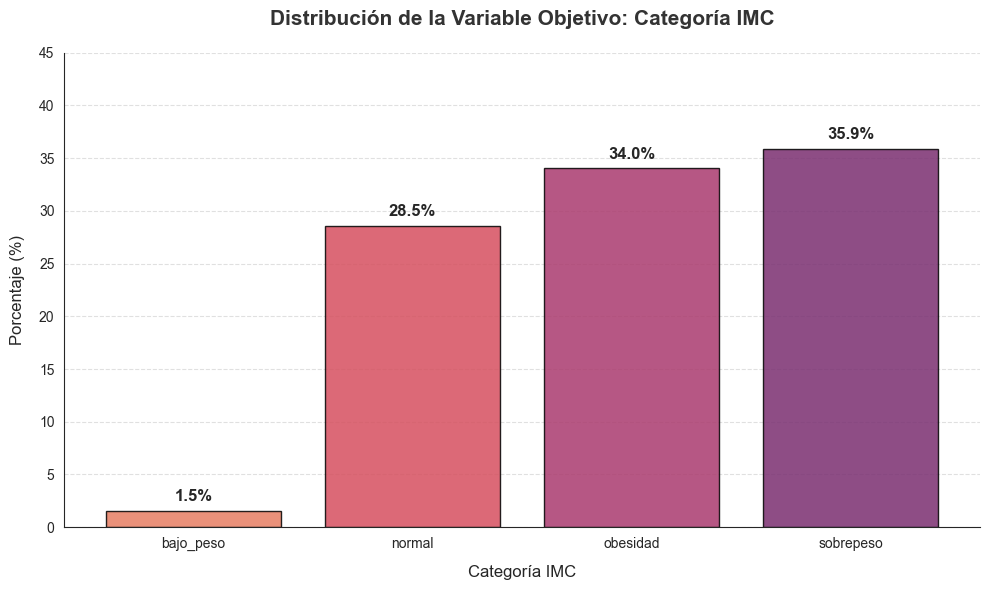

In [106]:
conteo = df["categoria_imc"].value_counts().sort_index()
porcentaje = (conteo / conteo.sum() * 100)

# 2. Configurar el gráfico con un estilo más limpio
sns.set_style("white") 
fig, ax = plt.subplots(figsize=(10, 6))

# Usamos la paleta 'viridis' o 'flare' que son muy estéticas
colores = sns.color_palette("flare", n_colors=len(porcentaje))

bars = ax.bar(porcentaje.index, porcentaje.values, 
              color=colores, 
              edgecolor="black", 
              linewidth=1,
              alpha=0.85)

# 3. Estética y etiquetas
ax.bar_label(bars, fmt="%.1f%%", padding=5, fontsize=12, weight="bold")
ax.set_title("Distribución de la Variable Objetivo: Categoría IMC", 
             fontsize=15, weight="bold", pad=20, color="#333333")

# Personalizar ejes
ax.set_xlabel("Categoría IMC", fontsize=12, labelpad=10)
ax.set_ylabel("Porcentaje (%)", fontsize=12, labelpad=10)
ax.set_ylim(0, 45)

# Eliminar los bordes (spines) superior y derecho para un look moderno
sns.despine()

# Añadir una línea de cuadrícula horizontal sutil
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# 4. Guardar y mostrar
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_distribucion_target_colores.png", dpi=150, bbox_inches="tight")
plt.show()

## Distribución de los predictores

Antes de modelar, inspeccionamos la distribución de cada variable
predictora para detectar anomalías, valores dominantes o comportamientos
inesperados. Esta inspección también nos permite identificar qué variables
tienen mayor variabilidad — una señal de que aportarán más información
al clasificador.

In [107]:
# variables continuas — valores numéricos reales con rango amplio
COLS_CONTINUAS = ["edad", "salud_fisica_mala", "salud_mental_mala"]

# variables categóricas — códigos numéricos con categorías discretas
COLS_CATEGORICAS = [
    col for col in df.columns
    if col not in COLS_CONTINUAS and col != "categoria_imc"
]


# Verificación de conteo
print(f"Variables Continuas: {len(COLS_CONTINUAS)}")   # 3
print(f"Variables Categóricas: {len(COLS_CATEGORICAS)}") # 8

Variables Continuas: 3
Variables Categóricas: 8


## Distribución de variables continuas

**Edad:** distribución relativamente uniforme entre 18 y 79 años con un
pico pronunciado en 80 — artefacto del protocolo CDC que agrupa a todos
los mayores de 80 en ese valor tope. No es un error sino una decisión
de diseño de la encuesta.

**Salud física mala y salud mental mala:** ambas variables presentan
distribución zero-inflated — la gran mayoría de encuestados reporta 0
días de mala salud, con una cola decreciente hacia 30 días. Este patrón
es idéntico al observado en `capital.gain` durante el Proyecto 00 con
CTGAN, y anticipa un desafío similar para el modelo generativo: capturar
correctamente la masa en cero sin generar valores negativos ni colapsar
la distribución.

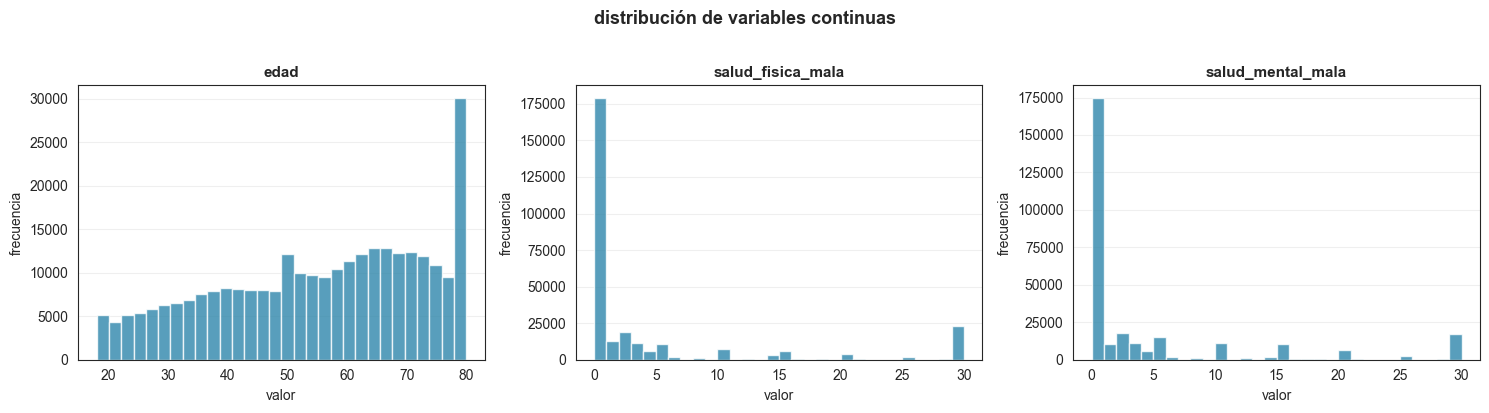

In [108]:
# visualización de predictores continuos — histogramas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(COLS_CONTINUAS):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=30, color="#2E86AB", alpha=0.8, edgecolor="white")
    ax.set_title(col, fontsize=11, weight="bold")
    ax.set_xlabel("valor")
    ax.set_ylabel("frecuencia")
    ax.grid(alpha=0.3, axis="y")

plt.suptitle("distribución de variables continuas", fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_distribucion_continuas.png", dpi=150, bbox_inches="tight")
plt.show()

## Distribución de variables predictoras categóricas

Las distribuciones revelan el perfil demográfico y de hábitos de la
muestra. El dataset está balanceado por sexo (50/50 aproximadamente).
En nivel educativo domina la población universitaria, y en ingresos
el rango `50k_100k` es el más frecuente — reflejo del sesgo de
participación típico en encuestas telefónicas hacia población con
mayor acceso y estabilidad.

La etnia blanca domina con el 75% de la muestra, lo que implica que
los hallazgos sobre otras etnias deben interpretarse con cautela dado
el menor volumen de datos. La gran mayoría realizó actividad física
en los últimos 30 días (77%) y nunca ha fumado (60%). El consumo de
alcohol muestra una distribución más equilibrada entre quienes consumen
y quienes no.

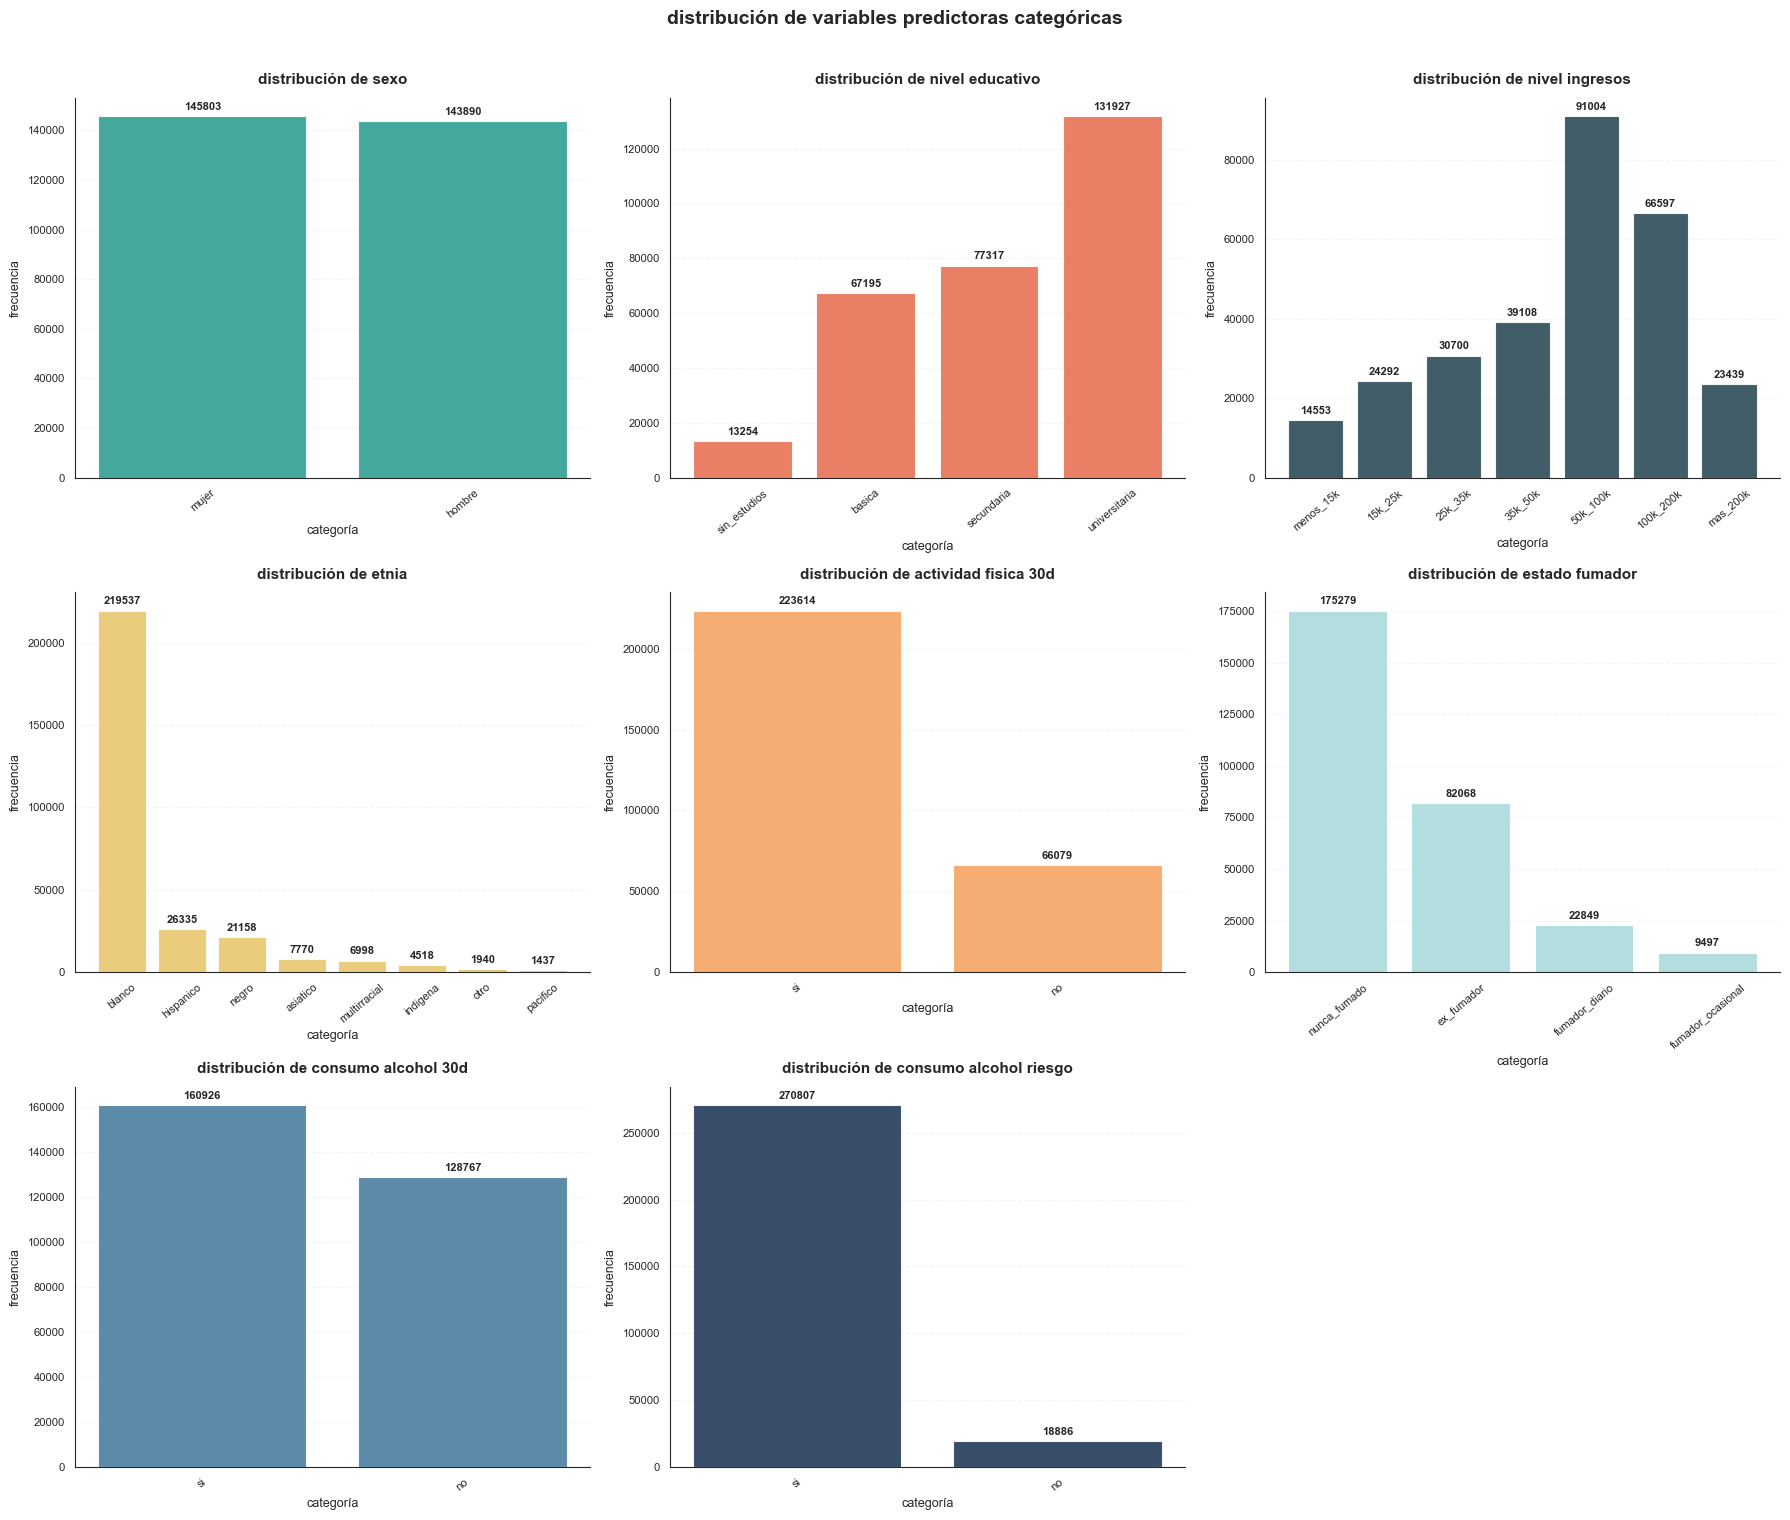

In [111]:
# 1. Limpieza de códigos de error (9.0) antes de mapear
# Esto asegura que el replace de MAPEO_CATEGORIAS no ignore strings

df = df.dropna()

# 2. Mapeo y conversión final a string para visualización
df = df.replace(MAPEO_CATEGORIAS)
for col in COLS_CATEGORICAS:
    df[col] = df[col].astype(str)

# 3. Visualización de predictores categóricos
# paleta de colores por variable para diferenciar visualmente
COLORES = [
    "#2A9D8F", "#E76F51", "#264653", "#E9C46A",
    "#F4A261", "#A8DADC", "#457B9D", "#1D3557", "#95D5B2"
]

# visualización de predictores categóricos
n = len(COLS_CATEGORICAS)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(COLS_CATEGORICAS):
    ax = axes[i]
    
    # ordenar según orden lógico si existe, sino por frecuencia
    conteo = df[col].value_counts()
    if col in ORDENES:
        conteo = conteo.reindex(ORDENES[col]).dropna()

    bars = ax.bar(
        conteo.index,
        conteo.values,
        color=COLORES[i % len(COLORES)],
        alpha=0.88,
        edgecolor="white",
        linewidth=0.8
    )

    ax.bar_label(bars, fmt="%d", padding=3, fontsize=8, fontweight="bold")
    ax.set_title(f"distribución de {col.replace('_', ' ')}", 
                 fontsize=11, weight="bold", pad=10)
    ax.set_xlabel("categoría", fontsize=9)
    ax.set_ylabel("frecuencia", fontsize=9)
    ax.tick_params(axis="x", rotation=40, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(alpha=0.2, axis="y", linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.suptitle("distribución de variables predictoras categóricas",
             fontsize=14, weight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_distribucion_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

## Análisis bivariado: proporción de IMC por predictor

Los gráficos de barras apiladas al 100% revelan patrones claros entre
los predictores y la categoría de IMC.

**Sexo:** los hombres presentan mayor proporción de sobrepeso, mientras
las mujeres muestran mayor proporción de obesidad. La diferencia es
moderada pero consistente con la literatura epidemiológica.

**Nivel educativo:** gradiente claro — a mayor educación, menor
proporción de obesidad. La población sin estudios tiene la mayor
concentración de obesidad, mientras la universitaria tiene la mayor
proporción de peso normal.

**Nivel de ingresos:** gradiente inverso marcado — a menor ingreso,
mayor obesidad. La categoría `menos_15k` tiene la proporción más alta
de obesidad. Esto refleja el acceso diferencial a alimentación saludable
y actividad física según nivel socioeconómico.

**Etnia:** las diferencias más marcadas del análisis. La población
asiática destaca con la mayor proporción de peso normal y bajo peso.
La población indígena y negra presentan las proporciones más altas de
obesidad — hallazgo consistente con disparidades documentadas en salud
pública estadounidense.

**Actividad física:** el predictor con diferencia más contrastante.
Quienes no realizaron actividad física en los últimos 30 días muestran
una proporción de obesidad notablemente mayor que quienes sí lo hicieron.

**Estado fumador:** los fumadores diarios muestran menor proporción de
obesidad que los no fumadores — hallazgo contraintuitivo que refleja el
efecto supresor del apetito del tabaco, no un efecto protector real.
Importante documentar para evitar interpretaciones erróneas.

**Alcohol:** diferencias pequeñas entre grupos. El consumo de alcohol
no parece ser un predictor fuerte de la categoría de IMC en este dataset
— hallazgo que el análisis de importancia de features confirmará o
refutará durante el modelado.

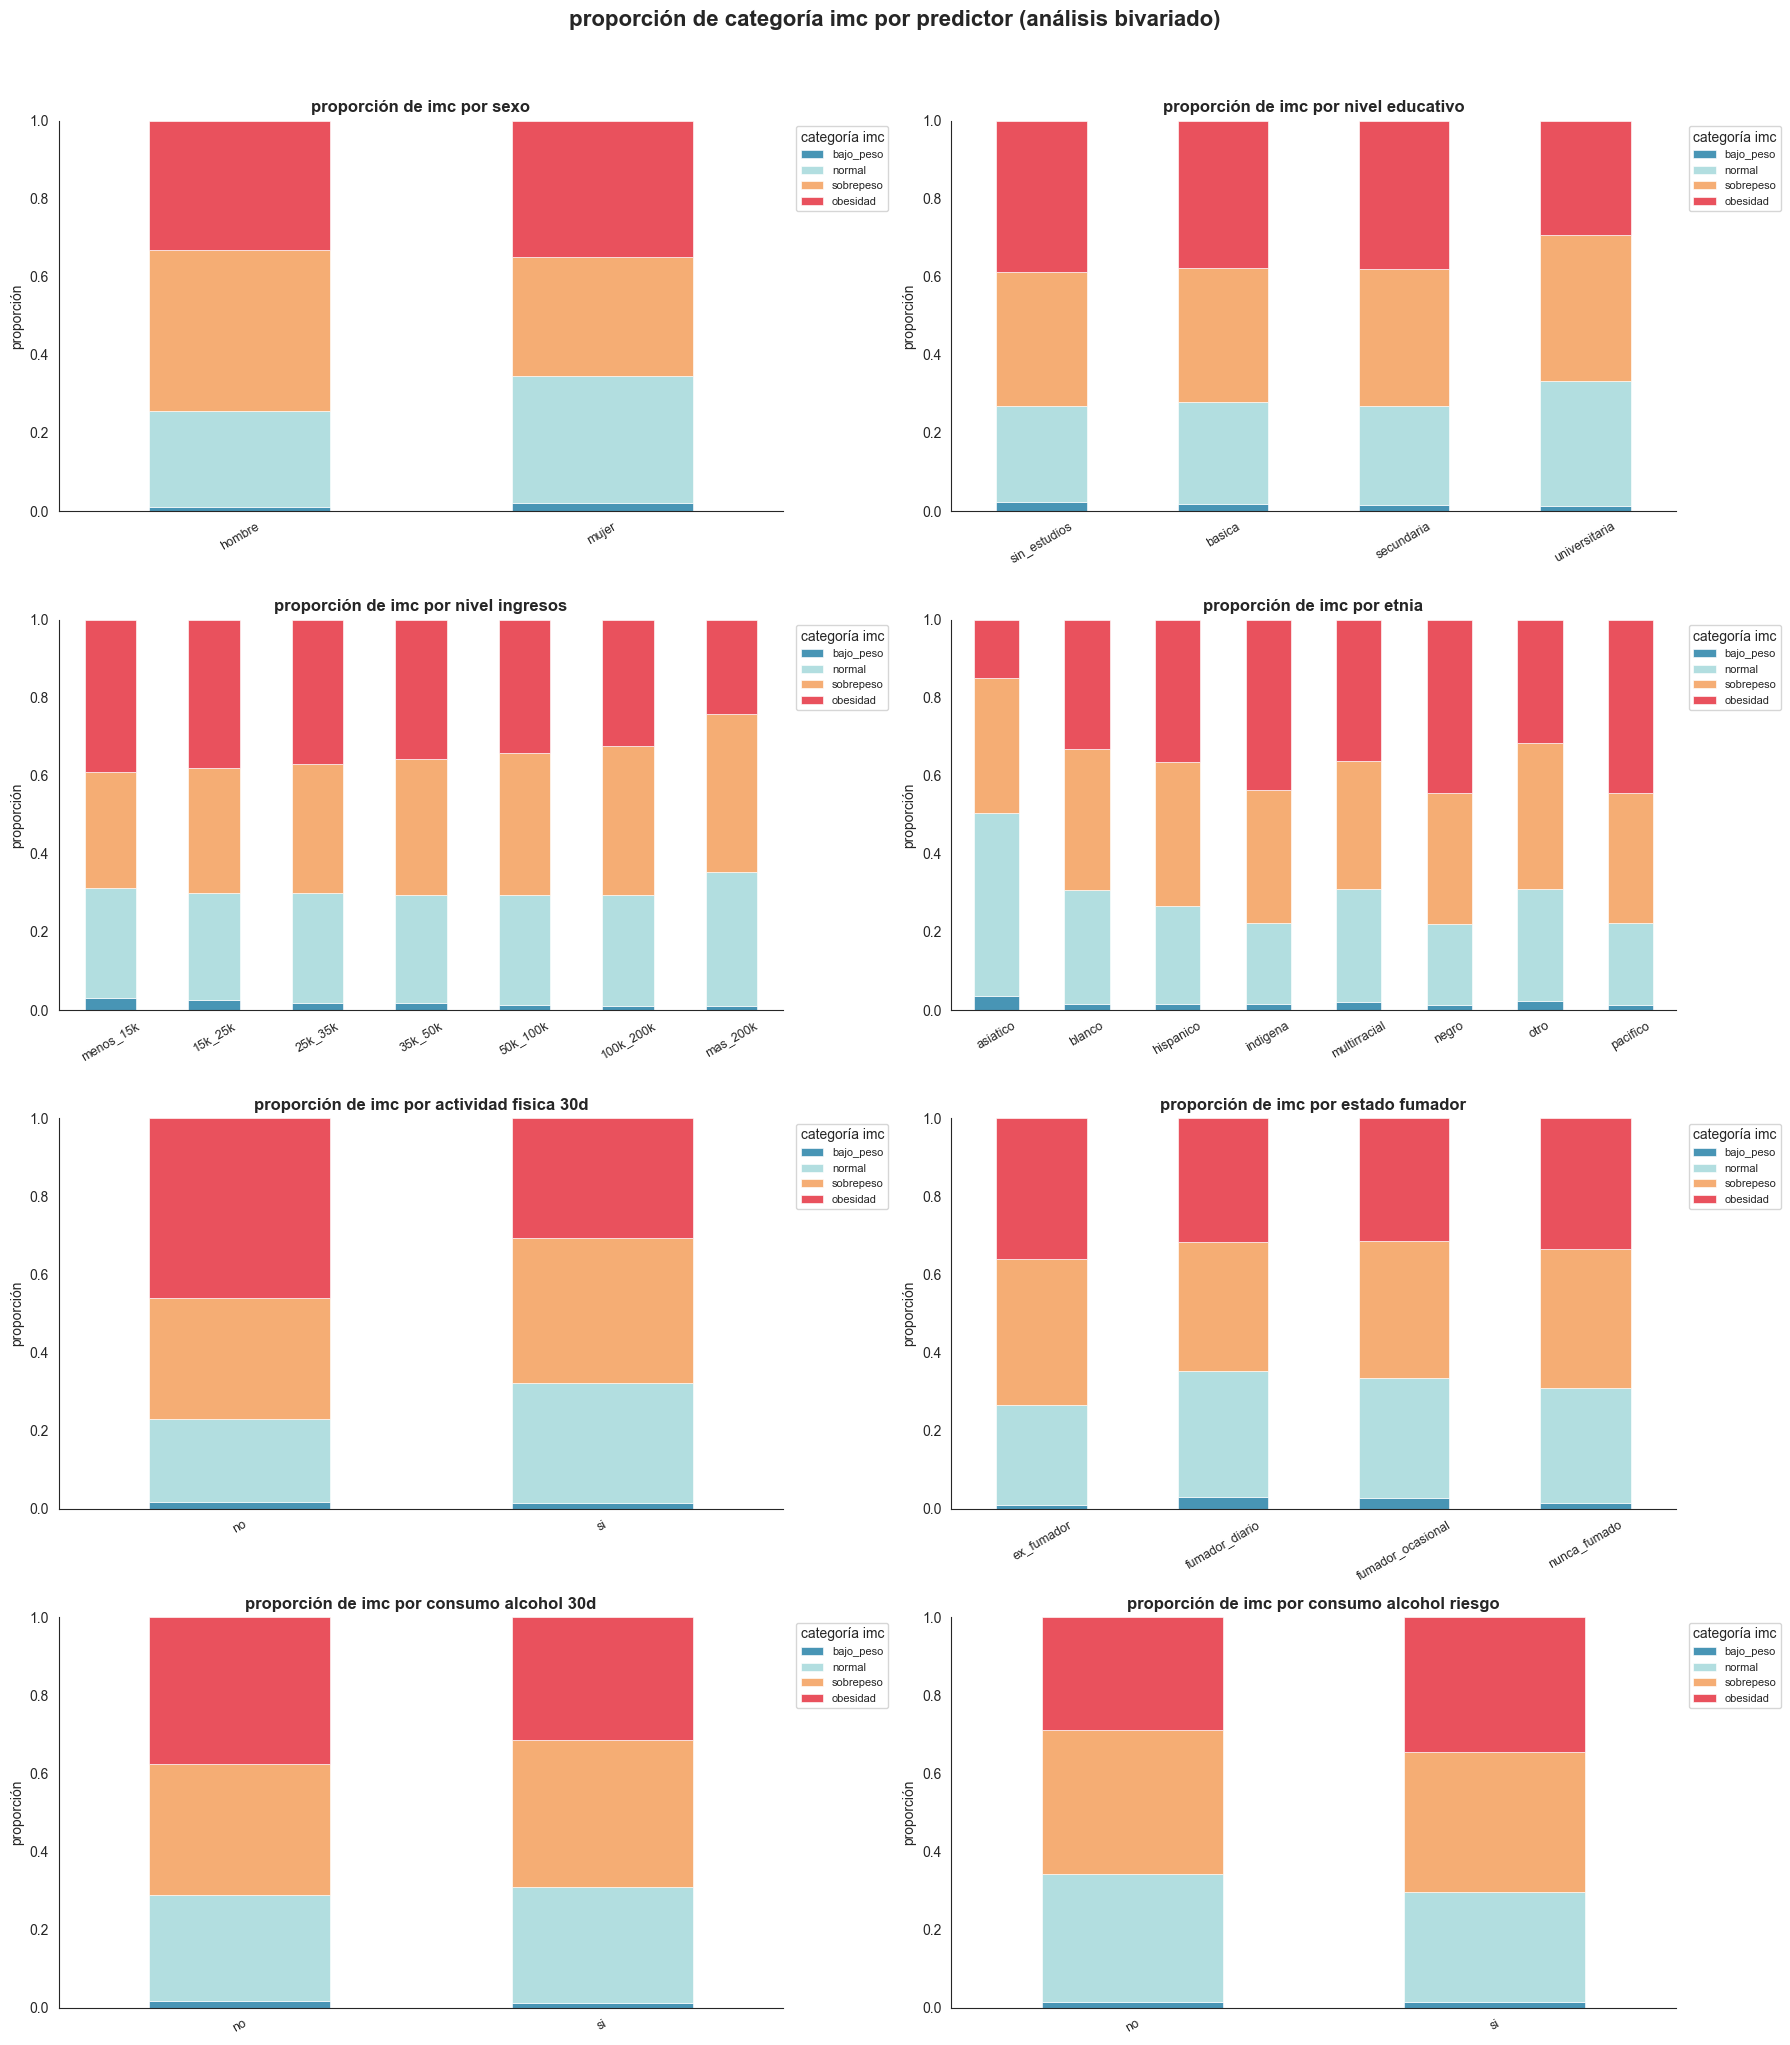

In [110]:
# 1. Definición de órdenes lógicos (Variables Ordinales)
ORDENES = {
    "categoria_imc": ["bajo_peso", "normal", "sobrepeso", "obesidad"],
    "salud_general": ["excelente", "muy_buena", "buena", "regular", "mala"],
    "nivel_ingresos": ["menos_15k", "15k_25k", "25k_35k", "35k_50k", "50k_100k", "100k_200k", "mas_200k"],
    "nivel_educativo": ["sin_estudios", "basica", "secundaria", "universitaria"]
}

# 2. Colores consistentes para el target
COLORES_IMC = {
    "bajo_peso": "#2E86AB", # Azul
    "normal":    "#A8DADC", # Cian claro
    "sobrepeso": "#F4A261", # Naranja
    "obesidad":  "#E63946"  # Rojo
}

# 3. Configuración de la figura
vars_analizar = [col for col in COLS_CATEGORICAS if col != "categoria_imc"]
n = len(vars_analizar)
n_cols = 2 # 2 columnas suele verse mejor para gráficos con leyenda externa
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(vars_analizar):
    ax = axes[i]

    # Crear tabla de contingencia normalizada (proporciones al 100%)
    tabla = pd.crosstab(df[col], df["categoria_imc"], normalize='index')
    
    # Reordenar COLUMNAS (IMC)
    tabla = tabla.reindex(columns=ORDENES["categoria_imc"])
    
    # Reordenar FILAS (si el predictor es ordinal)
    if col in ORDENES:
        tabla = tabla.reindex(ORDENES[col])

    # Graficar
    tabla.plot(
        kind="bar", 
        stacked=True, 
        ax=ax, 
        color=[COLORES_IMC[c] for c in ORDENES["categoria_imc"]],
        alpha=0.88, 
        edgecolor="white", 
        linewidth=0.5
    )

    # Estética
    ax.set_title(f"proporción de imc por {col.replace('_', ' ')}", fontsize=12, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("proporción")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.legend(title="categoría imc", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    sns.despine(ax=ax)

# Ocultar ejes vacíos
for j in range(n, len(axes)): axes[j].axis("off")

plt.suptitle("proporción de categoría imc por predictor (análisis bivariado)", 
             fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_imc_por_predictor.png", dpi=150, bbox_inches="tight")
plt.show()


## Análisis de correlación: variables continuas y categóricas

Para cuantificar la asociación entre predictores y el target, aplicamos
dos métricas complementarias según el tipo de variable.

**Pearson para variables continuas:** mide la relación lineal entre
`edad`, `salud_fisica_mala` y `salud_mental_mala`. Es el coeficiente
estándar pero tiene una limitación importante: solo detecta linealidad.
Una correlación baja no implica independencia si la relación es no lineal.

**V de Cramér para variables categóricas:** mide la fuerza de asociación
entre pares de variables nominales basándose en el estadístico Chi-cuadrado.
Su valor va de 0 (independencia total) a 1 (asociación perfecta). Es la
métrica correcta cuando los valores son categorías sin orden numérico real.

El análisis de correlación cumple dos objetivos: identificar qué
predictores tienen mayor asociación con `categoria_imc` — lo que
anticipará la importancia de features en el clasificador — y detectar
multicolinealidad entre predictores, que podría introducir redundancia
en el modelo generativo y distorsionar las distribuciones sintéticas.

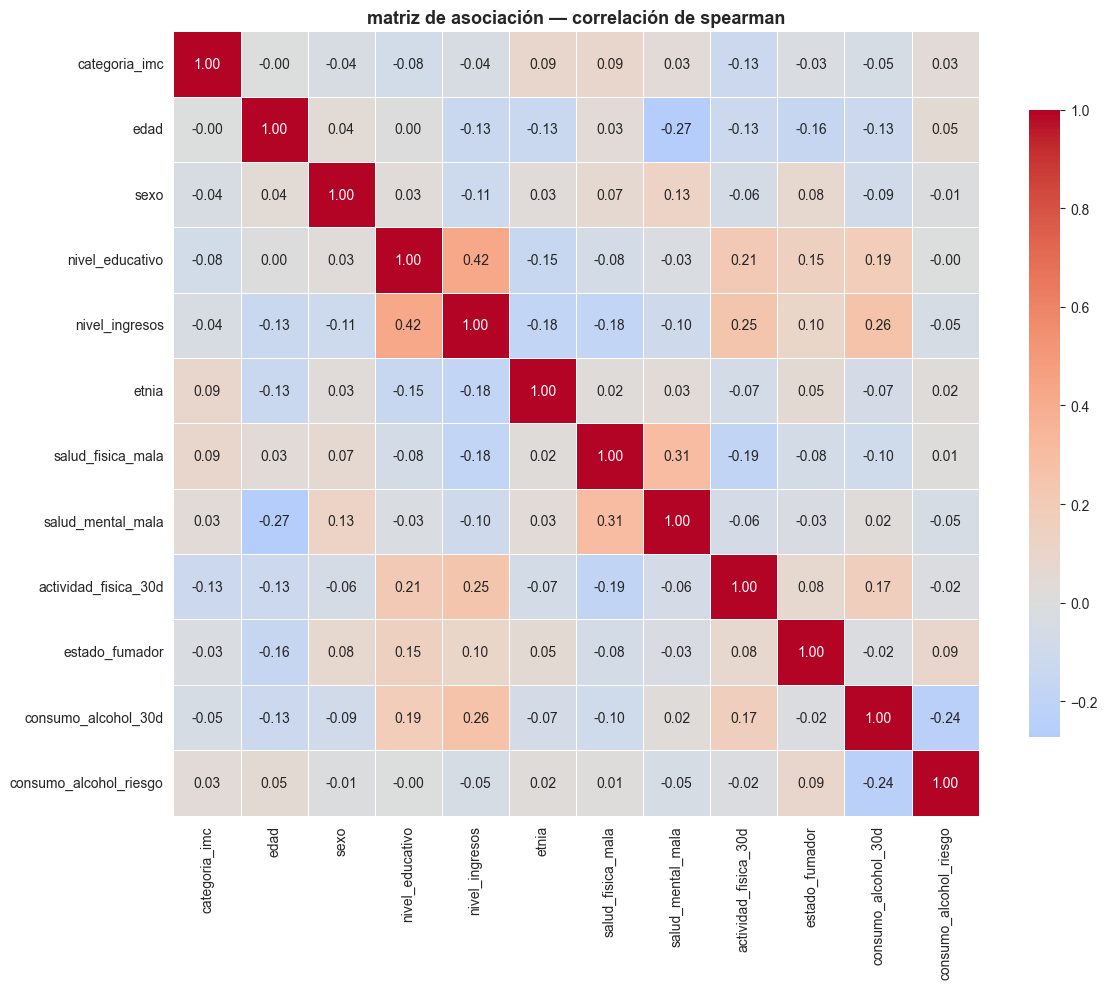

In [112]:
# copia para correlación
df_corr = df.copy()

# codificar con orden lógico para variables ordinales
for col, orden in ORDENES.items():
    if col in df_corr.columns:
        df_corr[col] = pd.Categorical(
            df_corr[col], 
            categories=orden, 
            ordered=True
        ).codes

# variables sin orden lógico definido — label encoding simple
cols_sin_orden = [c for c in COLS_CATEGORICAS 
                  if c not in ORDENES and c != "categoria_imc"]
for col in cols_sin_orden:
    df_corr[col] = df_corr[col].astype("category").cat.codes

# matriz de spearman
corr_matrix = df_corr.corr(method="spearman")

# visualización
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0,
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title("matriz de asociación — correlación de spearman", 
             fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

## Hallazgos de la matriz de correlación

**Correlaciones con el target (`categoria_imc`):**
Las asociaciones más fuertes con la categoría de IMC son
`actividad_fisica_30d` (-0.13) y `nivel_educativo` (-0.08),
ambas negativas — a mayor actividad física y educación, menor
categoría de IMC. Las variables de alcohol muestran correlaciones
cercanas a cero, confirmando lo observado en el análisis bivariado:
no son predictores fuertes de obesidad en este dataset.

**Multicolinealidad entre predictores:**
Se identificaron tres pares con correlación moderada:
`nivel_educativo` ↔ `nivel_ingresos` (0.42), `salud_fisica_mala`
↔ `salud_mental_mala` (0.31), y `consumo_alcohol_30d` ↔
`consumo_alcohol_riesgo` (-0.24). Ningún par supera el umbral
de 0.50 considerado preocupante, por lo que no se excluye ninguna
variable por redundancia. El par educación-ingresos es esperable
— ambas dimensiones del nivel socioeconómico tienden a moverse
juntas — pero aportan información diferente al modelo.

**Implicación para CTGAN:**
Correlaciones moderadas entre predictores son información valiosa
que el modelo generativo debe preservar. En el Proyecto 00
usamos la norma de Frobenius para medir qué tan bien CTGAN
conserva la estructura de correlaciones del dataset real —
aplicaremos la misma métrica aquí para evaluar la calidad de
los datos sintéticos generados.

In [113]:
# definir nombre del archivo procesado
archivo_salida = DATA_PROCESSED / "brfss_2023_cleaned.csv"

# guardar dataset limpio — index=False evita columna extra con índices
df.to_csv(archivo_salida, index=False)

print(f"archivo guardado en: {archivo_salida}")
print(f"dimensiones finales: {df.shape}")

archivo guardado en: ..\data\processed\brfss_2023_cleaned.csv
dimensiones finales: (289693, 12)
